# Diffraction on the different optical elements

In this notebook, we will simulate the propagation of a plane wave through the different optical elements from ```svetlanna.elements``` module

## Computational grid and simulation parameters
Firstly, we will set up the computational grid and simulation parameters. The computational grid defines the spatial resolution and size of the simulation, while the simulation parameters include the wavelength of the light, the distance of propagation, and the methods used for simulating the wavefront propagation

In [1]:
import torch

from svetlanna.elements import (
    FreeSpace,
    ThinLens,
    RectangularAperture,
    DiffractiveLayer,
)
from svetlanna import SimulationParameters
from svetlanna import Wavefront
from svetlanna.units import ureg

import matplotlib.pyplot as plt

In [2]:
lx = 1 * ureg.mm  # size along x-axis
ly = 1 * ureg.mm  # size along y-axis
Nx = 1300  # number of nodes along x-axis
Ny = 1300  # number of nodes along y-axis

dx = lx / Nx  # step along x-axis
dy = ly / Ny  # step along y-axis

z = 10 * ureg.mm  # propagation distance, mm

wl = 1064 * ureg.nm  # wavelength of the wavefront, nm

params = SimulationParameters(
    {
        "x": torch.linspace(-lx / 2, lx / 2, Nx),
        "y": torch.linspace(-ly / 2, ly / 2, Ny),
        "wavelength": wl,
    }
)

x_grid, y_grid = params.meshgrid(x_axis="W", y_axis="H")  # create computational grid

## Creating plane wave

We will create a plane wave using the ```Wavefront``` class from the ```svetlanna``` library. The plane wave will be defined by its wavelength and wavevector, which correspond to the direction of propagation

In [3]:
initial_wavefront = Wavefront.plane_wave(
    simulation_parameters=params, distance=10 * ureg.mm, wave_direction=[0, 0, 1]
)

## Free space between the element and the observation plane

We will consider the free space between the element and the observation plane, which is an important factor in determining the diffraction pattern. Furthermore, we will assume that plane of the element is parallel to the observation plane. The wavefront propagation from the element to the observation plane will be simulated using ```FreeSpace``` class from the ```svetlanna.elements``` module

In [4]:
z = 10 * ureg.mm  # propagation distance, mm
free_space = FreeSpace(simulation_parameters=params, distance=z, method="zpRSC")

## Thin lens

Collecting thin lens usually implemented to focus the light, but it can also be used to diverge the light. The focal length of the lens determines how strongly it focuses or diverges the light. A positive focal length corresponds to a converging lens, while a negative focal length corresponds to a diverging lens. The thin lens can be used in various applications, such as in cameras, microscopes, and telescopes, to manipulate the light and create clear images

In [5]:
focus = 10 * ureg.mm  # focal length of the thin lens, mm
aperture_size = 1 * ureg.mm  # size of the rectangular aperture, mm

lens = ThinLens(
    simulation_parameters=params,
    focal_length=focus,
    radius=aperture_size,
)

Let's observe the diffraction pattern of the plane wave after passing through the thin lens and propagating in free space

In [6]:
transmitted_wavefront = lens.forward(initial_wavefront)

output_wavefront = free_space.forward(transmitted_wavefront)

output_intensity = output_wavefront.intensity

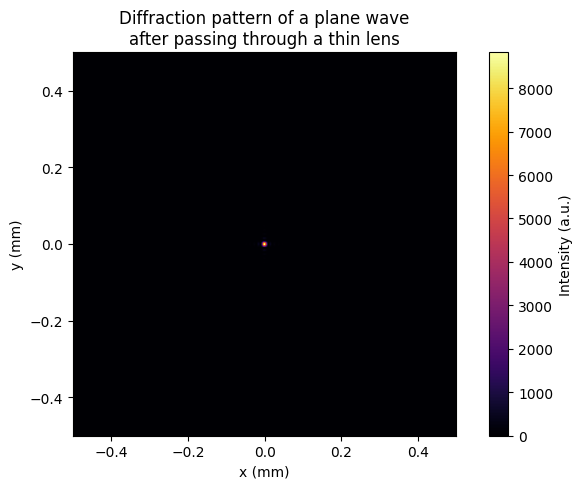

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.pcolormesh(
    x_grid * 1000, y_grid * 1000, output_intensity, shading="auto", cmap="inferno"
)

ax.set_xlabel("x (mm)")
ax.set_ylabel("y (mm)")
ax.set_title("Diffraction pattern of a plane wave\nafter passing through a thin lens")
ax.set_aspect("equal")
fig.colorbar(im, ax=ax, label="Intensity (a.u.)")
plt.tight_layout()

We can see that the incident wavefront determined as plane wave in the front focus plane of the lens is transformed into the spot in the back focus plane of the lens

## Rectangular aperture

On the same way as thin lens, we will calculate the diffraction pattern of the plane wave after passing through the rectangular aperture and propagating in free space

In [8]:
w = 0.2 * ureg.mm  # width of the rectangular aperture, mm
h = 0.2 * ureg.mm  # height of the rectangular aperture, mm

rect = RectangularAperture(simulation_parameters=params, width=w, height=h)

transmitted_wavefront = rect.forward(initial_wavefront)
output_wavefront = free_space.forward(transmitted_wavefront)
output_intensity = output_wavefront.intensity

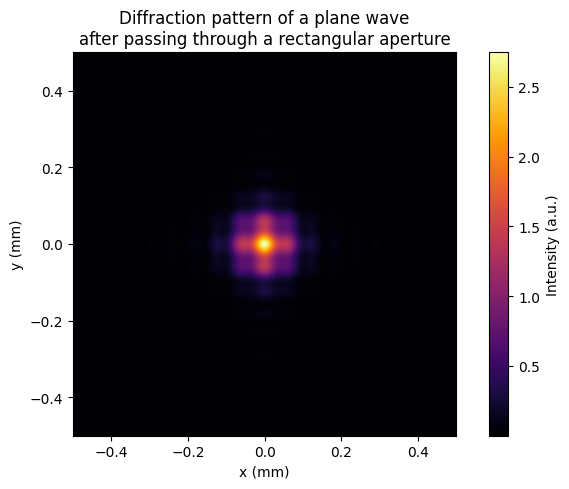

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.pcolormesh(
    x_grid * 1000, y_grid * 1000, output_intensity, shading="auto", cmap="inferno"
)

ax.set_xlabel("x (mm)")
ax.set_ylabel("y (mm)")
ax.set_title(
    "Diffraction pattern of a plane wave\nafter passing through a rectangular aperture"
)
ax.set_aspect("equal")
fig.colorbar(im, ax=ax, label="Intensity (a.u.)")
plt.tight_layout()

## 2D diffraction grating

In this section we will simulate the diffraction pattern of a plane wave after passing through a 2D diffraction grating determined by the diffraction layer. As you know, the transmission function of the diffraction layer is determined by the phase modulation. Thus, we will consider the phase modulation in the form of a 2D sinusoidal function, which corresponds to the 2D diffraction grating with sinusoidal surface relief. The period of the grating determines the spacing between the diffraction orders, while the amplitude of the phase modulation determines the intensity distribution among the diffraction orders. The 2D diffraction grating can be used in various applications, such as in spectroscopy, optical communication, and beam shaping, to manipulate the light and create specific diffraction patterns

In [10]:
grating_period = wl * 100

phase_function = torch.sin(2 * torch.pi * x_grid / grating_period) + torch.sin(
    2 * torch.pi * y_grid / grating_period
)

diffraction_layer = DiffractiveLayer(
    simulation_parameters=params, mask=torch.exp(1j * phase_function)
)

transmitted_wavefront = diffraction_layer.forward(initial_wavefront)
output_wavefront = free_space.forward(transmitted_wavefront)
output_intensity = output_wavefront.intensity

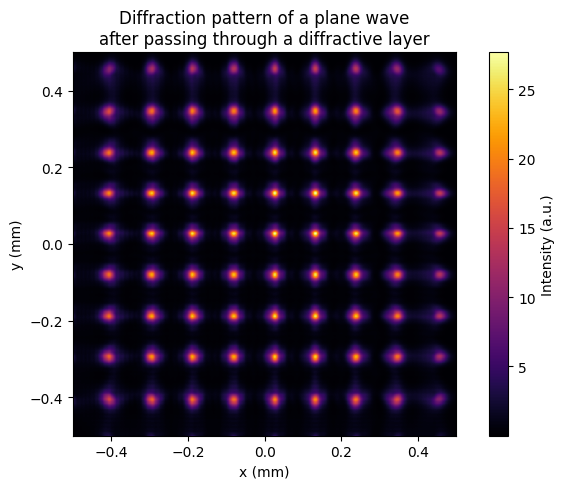

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.pcolormesh(
    x_grid * 1000, y_grid * 1000, output_intensity, shading="auto", cmap="inferno"
)

ax.set_xlabel("x (mm)")
ax.set_ylabel("y (mm)")
ax.set_title(
    "Diffraction pattern of a plane wave\nafter passing through a diffractive layer"
)
ax.set_aspect("equal")
fig.colorbar(im, ax=ax, label="Intensity (a.u.)")
plt.tight_layout()